RQ2 – Product and category performance

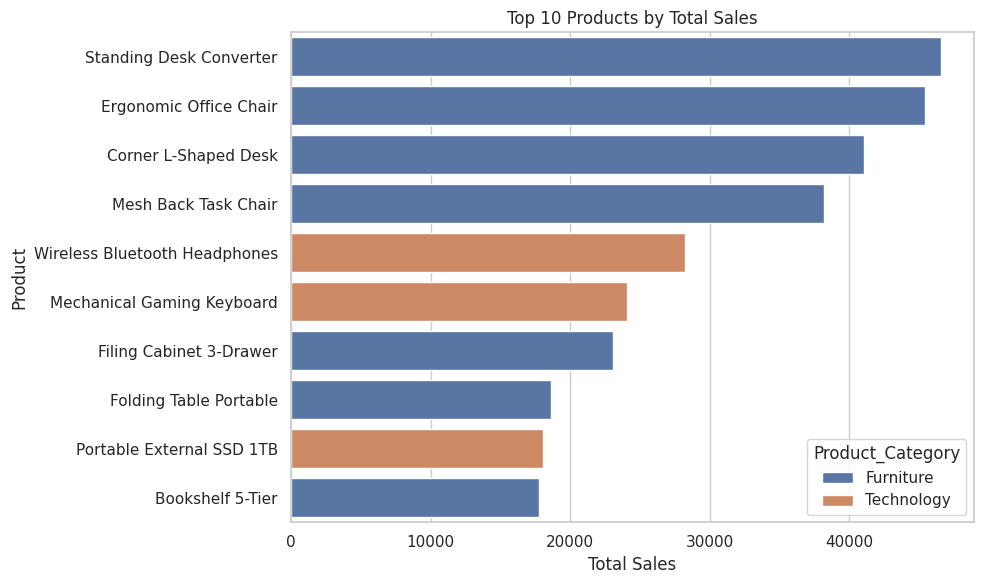

In [8]:
# RQ1: Regional and temporal sales & profit patterns

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -------------------
# 1. Load data
# -------------------
DATA_PATH = Path("/kaggle/input/datasets/bibirehana/global-e-commarce-sales-data-analysis/global_ecommerce_sales.csv")
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = Path("./rq2_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------
# 2. Aggregate by Product_Category
# -------------------
cat_summary = (
    df.groupby('Product_Category', as_index=False)
      .agg(
          Total_Sales=('Total_Sales', 'sum'),
          Total_Profit=('Profit', 'sum')
      )
      .sort_values('Total_Sales', ascending=False)
)

cat_summary.to_csv(OUTPUT_DIR / "RQ2_Table_Category_Sales_Profit.csv", index=False)

# -------------------
# 3. Aggregate by Product_Name
# -------------------
prod_summary = (
    df.groupby(['Product_Category', 'Product_Name'], as_index=False)
      .agg(
          Total_Sales=('Total_Sales', 'sum'),
          Total_Profit=('Profit', 'sum')
      )
      .sort_values('Total_Sales', ascending=False)
)

top_products = prod_summary.head(10)
top_products.to_csv(OUTPUT_DIR / "RQ2_Table_Top10_Products_Sales_Profit.csv", index=False)

# -------------------
# 4. Plot top products bar chart
# -------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_products,
    y='Product_Name',
    x='Total_Sales',
    hue='Product_Category'
)
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RQ2_Figure2_TopProducts_Sales.pdf", format="pdf")
plt.show()
plt.close()

### Interpretation of chart.

- Furniture dominates the top‑selling products, with items like Standing Desk Converter, Ergonomic Office Chair, and Corner L‑Shaped Desk leading the list.

- Technology products also perform strongly, especially Wireless Bluetooth Headphones, Mechanical Gaming Keyboard, and Portable External SSD 1TB.

- Standing Desk Converter is the single highest‑selling product, indicating strong global demand for ergonomic workspace solutions.

- Large office/furniture items consistently appear in the top ranks, suggesting high-value purchases significantly drive total sales.

- Technology items show competitive sales but generally fall below the top furniture items, reflecting slightly lower price points or purchase frequency.

- The mix of categories shows that both productivity‑related furniture and tech accessories are key revenue drivers in the dataset.

- No clothing or office‑supplies products appear in the top 10, highlighting their comparatively lower contribution to total sales.